# Measuring AI-Generated Content in Irish News — Presentation EDA


## Setup

In [7]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ROOT = Path.cwd().parent
DATA = ROOT / 'data'
DET_DIR = DATA / 'detection'
DETECTORS = ['perplexity', 'radar', 'binoculars', 'fastdetectgpt']

CATEGORY = {
    'rte': 'Legacy',
    'irish_examiner': 'Legacy',
    'the_liberal': 'Counter-consensus',
    'gript': 'Counter-consensus',
}

META_COLS = [
    'article_id', 'outlet', 'published_date', 'year', 'month',
    'period', 'section', 'author', 'is_wire', 'word_count',
]

SCORE_COLS = [f'{detector}_score' for detector in DETECTORS]


In [3]:
def load_scores(detector: str) -> pd.Series:
    """Load one detector's corpus scores keyed by article_id.

    Args:
        detector (str): Detector name.

    Returns:
        pd.Series: Float scores indexed by article_id, named <detector>_score.

    """
    frame = pd.read_csv(DET_DIR / f'{detector}.csv')
    frame.columns = ['id', 'score']
    corpus = frame[frame['id'].str.startswith('corpus:')].copy()
    corpus['article_id'] = corpus['id'].str.removeprefix('corpus:')
    return (
        corpus.set_index('article_id')['score']
        .astype(float)
        .rename(f'{detector}_score')
    )

In [6]:
df = pd.read_csv(DATA / 'corpus.csv', usecols=META_COLS)
df['category'] = df['outlet'].map(CATEGORY)
df['article_id'] = df['article_id'].astype(str)
for detector in DETECTORS:
    df = df.join(load_scores(detector), on='article_id')

df[['outlet', 'period', 'category', 'word_count', 'article_id', *SCORE_COLS]].head()

,outlet,period,category,word_count,article_id,perplexity_score,radar_score,binoculars_score,fastdetectgpt_score
0,gript,post,Counter-consensus,597,24151,-2.684621,0.010507,-0.988321,0.099189
1,gript,post,Counter-consensus,1082,24152,-2.503251,0.011878,-1.002437,-1.641121
2,gript,post,Counter-consensus,844,24153,-3.096333,0.011502,-1.018009,-1.473422
3,gript,post,Counter-consensus,1010,24154,-3.038991,0.006742,-1.028582,-1.780604
4,gript,post,Counter-consensus,350,47880,-2.859227,0.009843,-0.980833,0.081175


## 1. The corpus and its challenges

Before reading any detector score, we note the structural differences between outlets. Elements like length and wire content change detector scores *independently of AI*, and they line up with the legacy / counter-consensus split.

### 1.1 Composition

The design is deliberately balanced: 5,608 articles per outlet per period, 44,864 total.

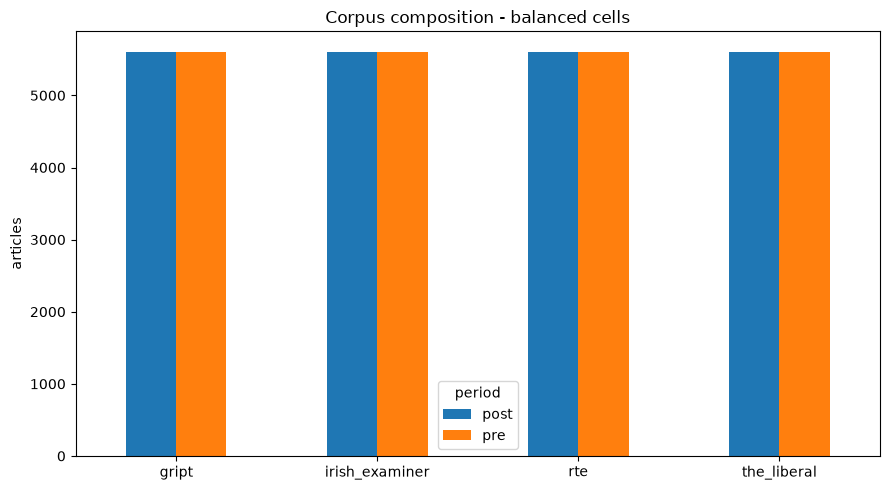

In [ ]:
comp = df.pivot_table(index='outlet', columns='period', aggfunc='size', fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
comp.plot(kind='bar', ax=ax)
ax.set_title('Corpus composition - balanced cells')
ax.set_xlabel('')
ax.set_ylabel('articles')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='period')
fig.tight_layout()